In [2]:
%%bash
# take 1,000 HQ random genomes from different UHGV species
# run vclust to calculate gani
# run protein similarity pipeine to calculate protein similarity
# compare the two results

# wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/votus_hq_plus.fna.gz

seqkit sample \
    ../figure_s8/votus_hq_plus.fna.gz \
    -n 1000 \
    -o votus_hq_plus_1k.fna.gz

[INFO] sample by number
[INFO] loading all sequences into memory...


Process is interrupted.


In [ ]:
%%bash
# cluster UHVDB at 95% ANI and 85% AF
vclust \
    prefilter \
    --in votus_hq_plus_1k.fna.gz \
    --out votus_hq_plus_1k.prefilter.txt \
    --threads 4 \
    --min-ident 0.7

vclust \
    align \
    --in votus_hq_plus_1k.fna.gz \
    --out votus_hq_plus_1k.ani.tsv \
    --filter votus_hq_plus_1k.prefilter.txt \
    --threads 4

In [ ]:
%%bash
pyrodigal-gv \
    -i votus_hq_plus_1k.fna.gz \
    -a votus_hq_plus_1k.pyrodigalgv.faa \
    --jobs 4

diamond \
    makedb \
    --threads 4 \
    --in votus_hq_plus_1k.pyrodigalgv.faa \
    -d votus_hq_plus_1k.pyrodigalgv.dmnd

diamond \
    blastp \
    --masking none \
    -e 1e-3 \
    --very-sensitive \
    --query votus_hq_plus_1k.pyrodigalgv.faa \
    --db votus_hq_plus_1k.pyrodigalgv.dmnd \
    --threads 4 \
    --outfmt 6 \
    --out votus_hq_plus_1k.diamond_blastp.tsv

python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/bin/uhvdb_selfscore.py \
    -i votus_hq_plus_1k.diamond_blastp.tsv \
    -o votus_hq_plus_1k.diamond_selfscore.tsv

python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/bin/uhvdb_normscore.py \
    -i votus_hq_plus_1k.diamond_blastp.tsv \
    -s votus_hq_plus_1k.diamond_selfscore.tsv \
    -t 4 \
    -m 0 \
    -o votus_hq_plus_1k.diamond_normscore.tsv

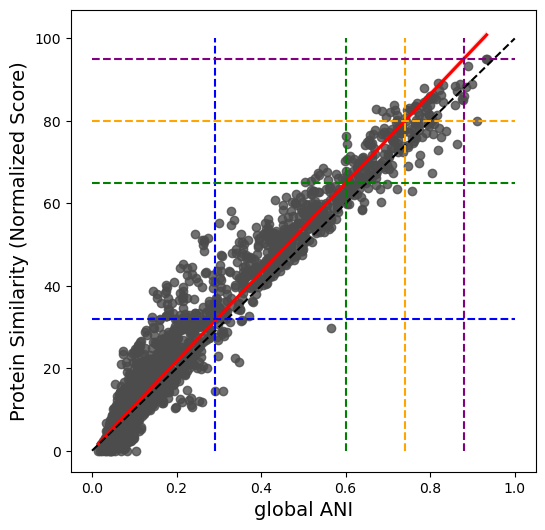

In [2]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

ani = pl.read_csv("../figure_s6/votus_hq_plus_1k.ani.tsv", separator="\t")
normscore = pl.read_csv("../figure_s6/votus_hq_plus_1k.diamond_normscore.tsv", separator="\t")

df = ani.join(
    normscore,
    left_on=["query", "reference"],
    right_on=["query", "reference"],
    how="full"
)

df = df.fill_null(0)
df = df.filter(pl.col("query") != pl.col("reference"))

plt.figure(figsize=(6,6))
sns.regplot(
    x="gani",
    y="norm_score",
    data=df,
    ci=99,
    line_kws=dict(color="r"),
    color=".3"
)
plt.xlabel("global ANI", fontdict={"size": 14})
plt.ylabel("Protein Similarity (Normalized Score)", fontdict={"size": 14})
# draw x=y line
plt.plot([0, 1], [0, 100], color="black", linestyle="--")
plt.plot([0.29, 0.29], [0, 100], color="blue", linestyle="--")
plt.plot([0.6, 0.6], [0, 100], color="green", linestyle="--")
plt.plot([0.74, 0.74], [0, 100], color="orange", linestyle="--")
plt.plot([0.88, 0.88], [0, 100], color="purple", linestyle="--")
plt.plot([0, 1], [32, 32], color="blue", linestyle="--")
plt.plot([0, 1], [65, 65], color="green", linestyle="--")
plt.plot([0, 1], [80, 80], color="orange", linestyle="--")
plt.plot([0, 1], [95, 95], color="purple", linestyle="--")

In [ ]:
df.filter((pl.col('gani') > 0) & (pl.col('norm_score') == 0)).shape[0]

14